## Dataset Distribution
This section shows the number of images in each class (with_mask / without_mask) across training, validation, and test sets to ensure the dataset is balanced and properly organized.

In [5]:
import os
import pandas as pd

base_dir = r"D:\face-mask-detection\data"

data = []

for split in ["train", "val", "test"]:
    for cls in ["WithMask", "WithoutMask"]:
        path = os.path.join(base_dir, split, cls)
        count = len(os.listdir(path))
        data.append([split, cls, count])

df = pd.DataFrame(data, columns=["Split", "Class", "Count"])
df

,Split,Class,Count
0,train,WithMask,5000
1,train,WithoutMask,5000
2,val,WithMask,400
3,val,WithoutMask,400
4,test,WithMask,483
5,test,WithoutMask,509


## Class Distribution (Training Set)
This bar chart shows the number of images in each class (WithMask and WithoutMask) inside the training set.  
It helps us understand whether the dataset is balanced, which is important for avoiding model bias during training.

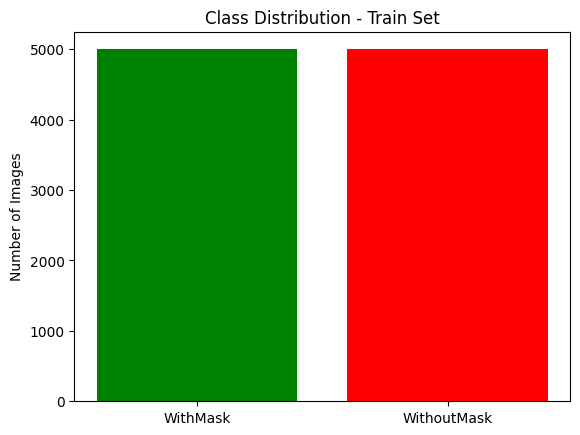

In [18]:
import os
import matplotlib.pyplot as plt

classes = ["WithMask", "WithoutMask"]
counts = [len(os.listdir(f'../data/train/{c}')) for c in classes]

plt.bar(classes, counts, color=['green', 'red'])
plt.title('Class Distribution - Train Set')
plt.ylabel('Number of Images')
plt.show()

## Sample Images (With Mask Class)
This visualization displays a random sample of images from the "WithMask" class.  
It helps us understand how people wearing masks appear in different lighting conditions, angles, and backgrounds, which is important for evaluating dataset diversity and model robustness.

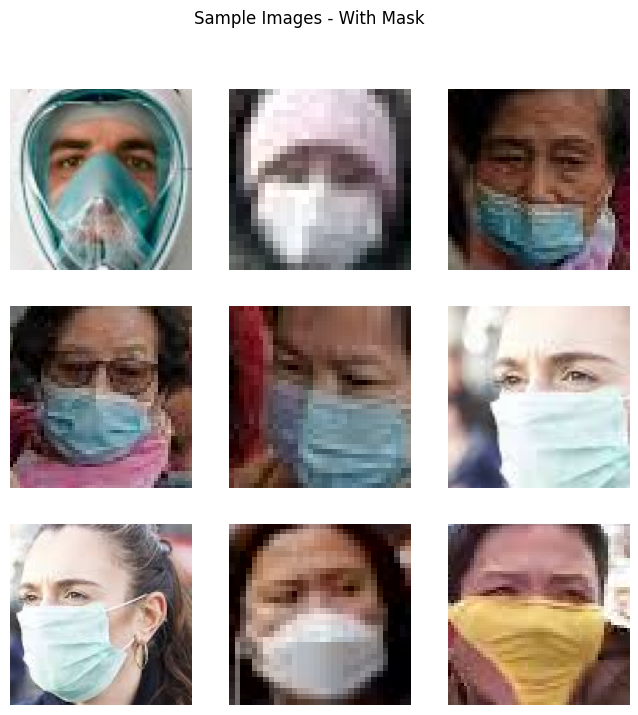

In [19]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

folder = '../data/train/WithMask'
images = os.listdir(folder)[:9]

fig, axes = plt.subplots(3, 3, figsize=(8, 8))
for ax, img_name in zip(axes.flatten(), images):
    img = mpimg.imread(f'{folder}/{img_name}')
    ax.imshow(img)
    ax.axis('off')
plt.suptitle('Sample Images - With Mask')
plt.show()

## Sample Images (Without Mask Class)
This visualization shows a random sample of images from the "WithoutMask" class.  
It helps us observe how faces appear without masks under different lighting conditions, angles, and backgrounds, which is useful for understanding dataset variability and improving model generalization.

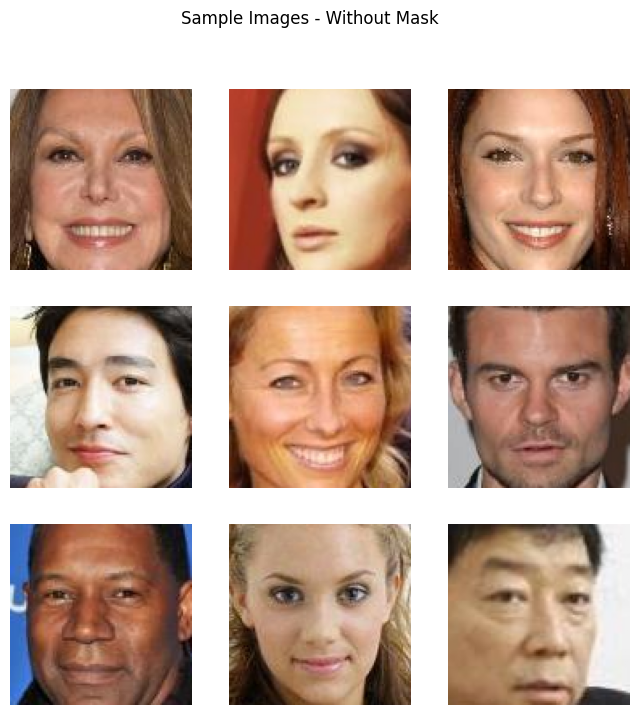

In [20]:
folder = '../data/train/WithoutMask'
images = os.listdir(folder)[:9]

fig, axes = plt.subplots(3, 3, figsize=(8, 8))
for ax, img_name in zip(axes.flatten(), images):
    img = mpimg.imread(f'{folder}/{img_name}')
    ax.imshow(img)
    ax.axis('off')
plt.suptitle('Sample Images - Without Mask')
plt.show()

## Dataset Split Distribution (With Percentages)
This chart shows the distribution of images across Train, Validation, and Test sets in both absolute numbers and percentages.  
It helps verify that the dataset is properly split and balanced, ensuring reliable model training and evaluation.

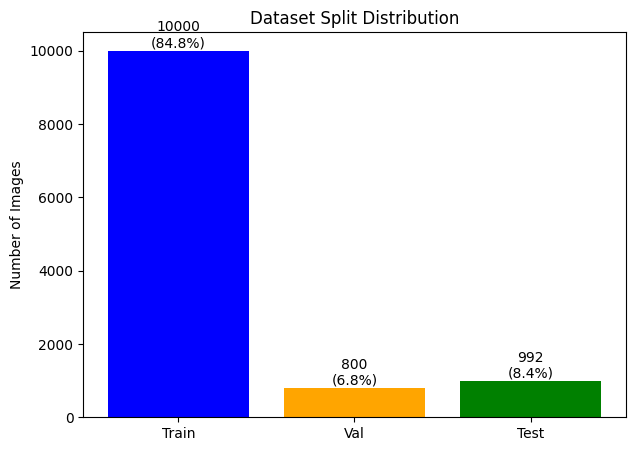

In [ ]:
import os
import matplotlib.pyplot as plt

base_dir = "../data"

splits = ["Train", "Val", "Test"]

counts = []

for split in splits:
    if split == "Train":
        total = len(os.listdir(f"{base_dir}/train/WithMask")) + len(os.listdir(f"{base_dir}/train/WithoutMask"))
    elif split == "Val":
        total = len(os.listdir(f"{base_dir}/val/WithMask")) + len(os.listdir(f"{base_dir}/val/WithoutMask"))
    else:
        total = len(os.listdir(f"{base_dir}/test/WithMask")) + len(os.listdir(f"{base_dir}/test/WithoutMask"))
    
    counts.append(total)

total_all = sum(counts)
percentages = [c / total_all * 100 for c in counts]

# Plot
plt.figure(figsize=(7,5))
bars = plt.bar(splits, counts, color=['blue', 'orange', 'green'])

for bar, count, pct in zip(bars, counts, percentages):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{count}\n({pct:.1f}%)",
        ha='center',
        va='bottom'
    )

plt.title("Dataset Split Distribution")
plt.ylabel("Number of Images")
plt.show()